# CCS3440 – Artificial Intelligence Coursework
## Selected Task: Option B – Patient Readmission Prediction
**Student ID:** 23UG1-0018, 23UG1-0151, 23UG1-0072, 23UG1-0069, CIT-23-02-0091

## Task 01 – Problem Definition and Literature Review

### 1. Problem Definition
The objective of this prediction task is to determine whether a discharged hospital inpatient will be readmitted to the hospital within 30 days of discharge (`readmitted_30_days`). This is formulated as a **binary classification** problem where:
- **Target variable (`readmitted_30_days`):**
  - `1` = Patient is readmitted within 30 days of discharge.
  - `0` = Patient is not readmitted.

*Target Cohort Definition:* The analysis is strictly restricted to discharged inpatients (`admitted == 1`). Outpatients (`admitted == 0`) are excluded from readmission risk modeling because outpatients have zero hospital stays and zero readmission events by definition. Including outpatients introduces trivial target correlation and data leakage where admission status dominates prediction rather than actual clinical risk factors.

### 2. Significance
Patient readmission within a short timeframe is a critical indicator of healthcare quality and operational efficiency:
- **Quality of Care:** High readmission rates often reflect suboptimal inpatient care, premature discharges, or inadequate post-discharge transitional care.
- **Financial Impact:** Unplanned readmissions result in significant unnecessary financial costs for healthcare providers and patients.
- **Resource Allocation:** Predicting hospital readmission risk allows clinicians to target high-risk patients with intensive follow-up care, reducing overall readmission rates and optimizing hospital bed capacity.

###### 3. Literature Review (5 Peer-Reviewed Research Papers)

Hospital readmission prediction has been widely studied using machine learning, electronic health records, and explainable AI methods. Five peer-reviewed studies were selected because they are directly relevant to patient readmission prediction, model performance, and interpretability.

- **Paper 1: Deep Learning on Electronic Health Records – Rajkomar et al. (2018) [1]**

  Rajkomar et al. developed deep learning models using large-scale electronic health record data. Their models achieved AUROC values of approximately **0.75–0.76** for 30-day hospital readmission prediction. The study showed that deep learning can identify complex patterns from large and detailed clinical datasets.

  This study is relevant to our project because it provides a useful performance benchmark. Our Random Forest model achieved a lower ROC-AUC of **0.5726**. One important reason for this difference is that our project uses only **330 synthetic inpatient records**, while Rajkomar et al. used a very large real-world EHR dataset.

- **Paper 2: Hospital Readmission Risk Models – Kansagara et al. (2011) [2]**

  Kansagara et al. conducted a systematic review of **30 studies covering 26 validated readmission prediction models**. Many models based mainly on administrative data showed weak predictive performance, with c-statistics commonly around **0.55–0.65**.

  This study is highly relevant to our project because our final Random Forest achieved a ROC-AUC of **0.5726**, which falls within this weak discrimination range. This shows that predicting hospital readmission is a difficult task, especially when the available clinical and social information is limited.

- **Paper 3: Explainable AI using SHAP – Lundberg and Lee (2017) [3]**

  Lundberg and Lee introduced **SHAP (SHapley Additive exPlanations)**, a framework used to explain how individual features contribute to machine learning predictions.

  SHAP is suitable for our project because the selected Random Forest contains many decision trees and is more difficult to interpret directly than a single decision tree. In this coursework, SHAP is used to provide global and individual-level explanations of the model's predictions.

- **Paper 4: Interpretable Machine Learning in Healthcare – Caruana et al. (2015) [4]**

  Caruana et al. studied interpretable machine learning models for healthcare applications, including pneumonia risk and 30-day hospital readmission. Their work demonstrated that a machine learning model can learn statistically strong but clinically misleading relationships when hidden treatment or workflow effects exist in the data.

  This is directly relevant to our project. During our analysis of the full SmartCare dataset, the `admitted` variable strongly influenced readmission prediction because outpatients could not be readmitted. By restricting the final model to discharged inpatients (`admitted == 1`), we reduced this artificial relationship and created a more meaningful prediction problem.

- **Paper 5: Electronic Model for 30-Day Readmission – Amarasingham et al. (2010) [5]**

  Amarasingham et al. developed and validated an automated electronic model to identify **heart-failure patients at risk of 30-day readmission or death using electronic medical record data**. Their readmission model achieved a c-statistic of approximately **0.72**.

  The study also showed the value of including richer clinical, social, and socioeconomic information when predicting patient outcomes. This is important for our project because the SmartCare dataset contains useful demographic, clinical, operational, and billing information, but it does not contain detailed longitudinal EHR records or many social determinants of health. This may partly explain the relatively low ROC-AUC achieved by our final model.

Overall, the literature shows that hospital readmission is a difficult prediction problem. Large and information-rich EHR datasets can provide better predictive performance [1], while models based on limited administrative or clinical variables often show weaker discrimination [2]. The studies also highlight the importance of model interpretability [3], [4] and richer clinical and social information [5]. These findings support the use of a leakage-free Random Forest model together with SHAP and permutation importance in this coursework.

### 4. Research Gaps & Proposed Approach
A review of existing clinical readmission modeling highlights three key research gaps:
1. **The Interpretability Tradeoff:** Advanced deep learning models (e.g., npj Digital Medicine [1]) achieve high scores but act as black boxes, making them difficult for clinicians to trust at the bedside. Conversely, simple scores (e.g., LACE [2]) yield low predictive accuracy (c-statistic 0.55-0.65). We bridge this gap by deploying a GridSearch-tuned Random Forest ensemble backed by global Permutation Importance and local SHAP attributions (Lundberg & Lee [3]).
2. **Evaluation Rigor & Socioeconomic Bias:** Simple 80:20 train-test splits can suffer from evaluation variance or data leakage. We address this gap by evaluating all models using **Stratified 5-Fold Cross-Validation**, with **nested GridSearchCV hyperparameter tuning for Random Forest**, comparing the **Baseline Full Dataset Cohort ($N=1000$)** and the **Refined Discharged Inpatient Cohort ($N=330$)**, encapsulating scaling, encoding, and feature selection inside leakage-free pipelines, and evaluating demographic subgroup performance across gender and age.
3. **Lack of Direct Clinical Translation:** Academic studies rarely validate their models through bedside prototype interfaces. We bridge this gap by building a bedside Streamlit calculator with integrated operational constraint checks to translate predictions into clinical workflow support.

# Task 02 – Dataset Ingestion & Understanding

We import the required libraries, configure reproducibility parameters, ingest the `smartcare_ai_dataset_1000.csv` dataset, inspect both the raw full dataset ($N=1000$) and the restricted inpatient cohort (`admitted == 1`, $N=330$), load the data dictionary, and examine the structure.


In [16]:
# Imports and reproducibility configuration
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "readmitted_30_days"
DATA_FILE = "smartcare_ai_dataset_1000.csv"
DICTIONARY_FILE = "smartcare_ai_dataset_data_dictionary.csv"

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# Trigger the interactive file gateway to upload local CSV (for Google Colab)
try:
    from google.colab import files
    print("Colab environment detected. Triggering file upload widget:")
    uploaded = files.upload()
except ImportError:
    print("Non-Colab environment. Proceeding with local dataset files.")

# Ingest raw dataset
raw_df = pd.read_csv(DATA_FILE)
print("\nSmartCare raw dataset loaded successfully!")
print(f"Raw Dataset Dimension: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")



Colab environment detected. Triggering file upload widget:


Saving smartcare_ai_dataset_1000.csv to smartcare_ai_dataset_1000.csv
Saving smartcare_ai_dataset_data_dictionary.csv to smartcare_ai_dataset_data_dictionary.csv

SmartCare raw dataset loaded successfully!
Raw Dataset Dimension: 1000 rows, 33 columns


In [17]:
# Restrict cohort to discharged inpatients (admitted == 1) to model true clinical risk
df = raw_df[raw_df['admitted'] == 1].copy().reset_index(drop=True)
print(f"\nCohort Filtering: Restricted analysis to discharged inpatients (admitted == 1).")
print(f"Inpatient Cohort Dimension: {df.shape[0]} rows, {df.shape[1]} columns")

# Load and display the data dictionary for structural understanding
data_dict = pd.read_csv(DICTIONARY_FILE)
print("\n--- Data Dictionary Overview ---")
display(data_dict)


Cohort Filtering: Restricted analysis to discharged inpatients (admitted == 1).
Inpatient Cohort Dimension: 330 rows, 33 columns

--- Data Dictionary Overview ---


,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


### Data Dictionary Interpretation

The provided data dictionary contains all 33 original dataset attributes and their meanings. For this Option B task:
- **Target variable:** `readmitted_30_days` (`1 = Readmitted`, `0 = Not Readmitted`).
- **Main input groups:** demographic (`age`, `gender`, `blood_group`), hospital/appointment history, admission and stay information, clinical measurements, treatment/laboratory counts, and billing/payment information.
- **Columns excluded from model inputs:** identifiers (`record_id`, `patient_id`), date (`appointment_date`), targets belonging to other coursework options (`no_show`, `disease_risk_level`), and `admitted` after the inpatient cohort is fixed.

The complete attribute names and descriptions are displayed from `smartcare_ai_dataset_data_dictionary.csv` above.

Display the first few rows of the inpatient dataset to verify structure and content.

In [18]:
# Display the first 5 records of the inpatient cohort
df.head()

,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,6,P10006,50,Female,A+,Neurology,Back Pain,2025-10-13,43,1,...,2500,45000,0,10251,57751,Unpaid,Card,1,1,Medium
1,12,P10012,38,Female,A-,Cardiology,Fracture,2025-10-26,39,2,...,2000,25000,0,14744,41744,Paid,Card,0,0,Medium
2,16,P10016,90,Male,O-,Pediatrics,Chest Pain,2025-11-19,42,7,...,3500,10500,4800,2252,21052,Paid,Cash,1,1,High
3,20,P10020,53,Female,B-,General Medicine,Fracture,2025-10-30,31,1,...,2500,0,7200,12442,22142,Paid,Card,1,1,Medium
4,22,P10022,32,Female,O-,Laboratory Services,Kidney Infection,2025-07-16,5,1,...,2000,0,15000,18456,35456,Paid,Insurance,1,1,Low


Analyze the data types, non-null values, and summary statistics of numeric columns in the inpatient cohort.

In [19]:
# Check dataset info for data types and non-null values
print("--- Inpatient Dataset Information ---")
df.info()

# Show descriptive summary statistics for numerical attributes
print("\n--- Descriptive Statistics Summary (Inpatient Cohort) ---")
display(df.describe().T)

--- Inpatient Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     330 non-null    int64  
 1   patient_id                    330 non-null    object 
 2   age                           330 non-null    int64  
 3   gender                        330 non-null    object 
 4   blood_group                   330 non-null    object 
 5   department                    330 non-null    object 
 6   diagnosis                     330 non-null    object 
 7   appointment_date              330 non-null    object 
 8   waiting_days                  330 non-null    int64  
 9   previous_appointments         330 non-null    int64  
 10  missed_previous_appointments  330 non-null    int64  
 11  appointment_status            330 non-null    object 
 12  admitted                  

,count,mean,std,min,25%,50%,75%,max
record_id,330.0,503.236364,292.368785,6.0,254.75,508.0,745.75,998.0
age,330.0,44.260606,16.740064,1.0,33.00,45.0,55.75,90.0
waiting_days,330.0,22.618182,13.251815,0.0,12.00,22.0,35.00,44.0
previous_appointments,330.0,2.887879,1.630682,0.0,2.00,3.0,4.00,7.0
missed_previous_appointments,330.0,0.533333,0.764194,0.0,0.00,0.0,1.00,4.0
admitted,330.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
length_of_stay_days,330.0,3.342424,1.812072,1.0,2.00,3.0,5.00,9.0
previous_admissions,330.0,0.875758,1.019425,0.0,0.00,1.0,1.00,5.0
systolic_bp,330.0,129.096970,15.634396,85.0,118.00,130.0,139.00,178.0
diastolic_bp,330.0,78.915152,9.744397,56.0,72.00,79.0,86.00,106.0


Assess the target variable balance. First show the full dataset counts, then show the inpatient cohort counts used for the model.

In [20]:
# Check target variable distribution in the full dataset
print("\nReadmission counts in the full dataset:")
readmission_counts = raw_df[TARGET].value_counts().sort_index()
print(f"Not readmitted within 30 days: {readmission_counts.get(0, 0)}")
print(f"Readmitted within 30 days: {readmission_counts.get(1, 0)}")

print("\nTarget variable percentage distribution (Full Dataset):")
print(raw_df[TARGET].value_counts(normalize=True).sort_index() * 100)

# Check target variable distribution for discharged inpatients used for the model
print("\nTarget variable 'readmitted_30_days' frequency counts (Inpatient Cohort):")
print(df[TARGET].value_counts())
print("\nTarget variable percentage distribution (Inpatient Cohort):")
print(df[TARGET].value_counts(normalize=True) * 100)



Readmission counts in the full dataset:
Not readmitted within 30 days: 747
Readmitted within 30 days: 253

Target variable percentage distribution (Full Dataset):
readmitted_30_days
0    74.7
1    25.3
Name: proportion, dtype: float64

Target variable 'readmitted_30_days' frequency counts (Inpatient Cohort):
readmitted_30_days
1    253
0     77
Name: count, dtype: int64

Target variable percentage distribution (Inpatient Cohort):
readmitted_30_days
1    76.666667
0    23.333333
Name: proportion, dtype: float64


# Task 03 – Data Preprocessing & Feature Engineering

### Preprocessing & Data Cleaning Decisions:

1. **Cohort Selection (Leakage Prevention):** Filtering to `admitted == 1` eliminates the constant outpatient zero-readmission bias.
2. **Missing Value Handling:** In both cohorts, missing `room_type` values are imputed with `'None'` (representing Unknown/Unassigned) to prevent data deletion.
3. **Duplicate Record Detection:** Zero duplicate rows were found in the dataset, confirming data integrity.
4. **Outlier Identification:** An IQR analysis is performed on numerical features (`age`, `length_of_stay_days`, `total_bill_lkr`, `bmi`). Severe cases (long stays, high bills) represent critical clinical ICU events and are retained to preserve high-risk indicators.
5. **Feature Leakage Prevention:** Identifiers (`record_id`, `patient_id`), appointment dates, non-relevant targets (`no_show`, `disease_risk_level`), and `admitted` (which is constant `1` for all inpatients) are dropped from predictors.
6. **Feature Engineering:** Three clinical/operational metrics are constructed:
   - `pulse_pressure`: Difference between systolic and diastolic blood pressure (`systolic_bp - diastolic_bp`).
   - `missed_ratio`: Ratio of missed appointments (`missed_previous_appointments / (previous_appointments + 1)`).
   - `charge_per_day`: Charges relative to length of stay (`total_bill_lkr / (length_of_stay_days + 1)`).
7. **Encapsulated Preprocessing & Feature Selection:** Numerical scaling with `StandardScaler`, categorical encoding with `OneHotEncoder(drop='first', handle_unknown='ignore')`, and `SelectPercentile` feature selection are fitted inside each scikit-learn model `Pipeline`. The three engineered features are calculated before the pipeline because they use only predictor values and not the target.
8. **Rigorous Evaluation Strategy:** We use **Stratified 5-Fold Cross-Validation** across the inpatient cohort ($N=330$).
   - **Outer 5-Fold Stratified CV:** Evaluates all three coursework models and generates out-of-fold Accuracy, Precision, Recall, F1-Score, ROC-AUC, and confusion-matrix results.
   - **Inner 5-Fold Stratified CV inside GridSearchCV:** Used only for the Random Forest to select `max_depth` and `n_estimators` without using the outer validation fold.


In [21]:
# Check missing values in inpatient cohort
print("Missing Values in Inpatient Cohort:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Handle missing values in 'room_type' by replacing NaN with 'None'
df['room_type'] = df['room_type'].fillna('None')
raw_df['room_type'] = raw_df['room_type'].fillna('None')

# Verify zero remaining missing values
total_missing = df.isnull().sum().sum()
print(f"Total remaining missing values: {total_missing}")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Identify outliers using IQR method for key numerical features
num_check_cols = ['age', 'length_of_stay_days', 'total_bill_lkr', 'bmi']
print("\n--- Outlier Detection Analysis (IQR Method - Inpatients) ---")
for col in num_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"Feature: {col:<20} | Q1: {Q1:<6.1f} | Q3: {Q3:<6.1f} | IQR: {IQR:<6.1f} | Outliers: {outliers_count}")

# Create engineered clinical features for inpatient cohort
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
df['missed_ratio'] = df['missed_previous_appointments'] / (df['previous_appointments'] + 1)
df['charge_per_day'] = df['total_bill_lkr'] / (df['length_of_stay_days'] + 1)

# Create engineered clinical features for raw full dataset (for Baseline comparison)
raw_df['pulse_pressure'] = raw_df['systolic_bp'] - raw_df['diastolic_bp']
raw_df['missed_ratio'] = raw_df['missed_previous_appointments'] / (raw_df['previous_appointments'] + 1)
raw_df['charge_per_day'] = raw_df['total_bill_lkr'] / (raw_df['length_of_stay_days'] + 1)

print("\nEngineered features successfully created. Sample records:")
display(df[['pulse_pressure', 'missed_ratio', 'charge_per_day']].head())

# Drop identifiers, non-relevant targets, and constant 'admitted' feature
drop_columns = ['record_id', 'patient_id', 'appointment_date', 'no_show', 'disease_risk_level', 'admitted', TARGET]

X = df.drop(columns=drop_columns)
y = df[TARGET]

print(f"\nPredictors matrix shape X: {X.shape}")
print(f"Target vector shape y: {y.shape}")

# Categorize predictors into numerical and categorical subgroups
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numerical columns for scaling: {num_cols}")
print(f"Categorical columns for encoding: {cat_cols}")

# Build ColumnTransformer: scale numerical values, one-hot encode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

print("ColumnTransformer preprocessor established successfully.")

Missing Values in Inpatient Cohort:
room_type    236
dtype: int64
Total remaining missing values: 0
Number of duplicate rows: 0

--- Outlier Detection Analysis (IQR Method - Inpatients) ---
Feature: age                  | Q1: 33.0   | Q3: 55.8   | IQR: 22.8   | Outliers: 3
Feature: length_of_stay_days  | Q1: 2.0    | Q3: 5.0    | IQR: 3.0    | Outliers: 0
Feature: total_bill_lkr       | Q1: 17579.5 | Q3: 30811.8 | IQR: 13232.2 | Outliers: 23
Feature: bmi                  | Q1: 22.8   | Q3: 28.4   | IQR: 5.6    | Outliers: 5

Engineered features successfully created. Sample records:


,pulse_pressure,missed_ratio,charge_per_day
0,41,0.000000,9625.166667
1,70,0.333333,20872.000000
2,30,0.375000,5263.000000
3,49,0.000000,5535.500000
4,46,0.000000,8864.000000



Predictors matrix shape X: (330, 29)
Target vector shape y: (330,)
Numerical columns for scaling: ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'pulse_pressure', 'missed_ratio', 'charge_per_day']
Categorical columns for encoding: ['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status', 'room_type', 'payment_status', 'payment_method']
ColumnTransformer preprocessor established successfully.


### Feature Selection & Preprocessing Verification inside Pipeline

In [22]:
# Fit preprocessor on dataset to verify output dimensions and feature selection
X_preprocessed = preprocessor.fit_transform(X, y)
feature_names_out = preprocessor.get_feature_names_out()

selector = SelectPercentile(score_func=f_classif, percentile=80)
X_selected = selector.fit_transform(X_preprocessed, y)
selected_mask = selector.get_support()

selected_features = [feature_names_out[i] for i, sel in enumerate(selected_mask) if sel]
eliminated_features = [feature_names_out[i] for i, sel in enumerate(selected_mask) if not sel]

print(f"Feature Selection Complete: Selected {len(selected_features)} features out of {len(feature_names_out)} preprocessed features.")
print("\n--- Selected Features ---")
print(selected_features)
print("\n--- Eliminated Features ---")
print(eliminated_features)

Feature Selection Complete: Selected 44 features out of 55 preprocessed features.

--- Selected Features ---
['num__age', 'num__waiting_days', 'num__previous_appointments', 'num__missed_previous_appointments', 'num__length_of_stay_days', 'num__previous_admissions', 'num__diastolic_bp', 'num__blood_sugar_mg_dl', 'num__cholesterol_mg_dl', 'num__bmi', 'num__lab_tests_count', 'num__treatments_count', 'num__consultation_fee_lkr', 'num__room_charge_lkr', 'num__lab_charge_lkr', 'num__medicine_charge_lkr', 'num__total_bill_lkr', 'num__missed_ratio', 'cat__gender_Male', 'cat__blood_group_A-', 'cat__blood_group_AB+', 'cat__blood_group_AB-', 'cat__blood_group_B-', 'cat__blood_group_O+', 'cat__department_Laboratory Services', 'cat__department_Neurology', 'cat__department_Orthopedics', 'cat__department_Pediatrics', 'cat__department_Radiology', 'cat__diagnosis_Back Pain', 'cat__diagnosis_Chest Pain', 'cat__diagnosis_Fever', 'cat__diagnosis_Fracture', 'cat__diagnosis_Hypertension', 'cat__diagnosis_Ki

# Task 04 – Exploratory Data Analysis (EDA)

We visualize class balances, attribute relationships, distributions, and correlation patterns within the inpatient cohort, displaying each plot figure individually one by one.

### Visual 1: Inpatient Readmission Target Distribution

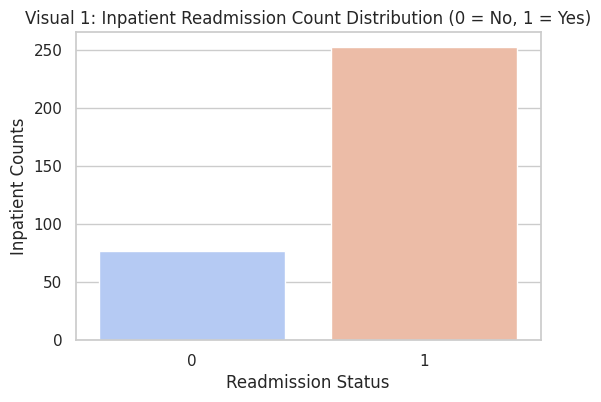

In [23]:
# Visual 1: Target Class Countplot
plt.figure(figsize=(6, 4))
sns.countplot(x=df[TARGET], hue=df[TARGET], palette='coolwarm', legend=False)
plt.title("Visual 1: Inpatient Readmission Count Distribution (0 = No, 1 = Yes)")
plt.xlabel("Readmission Status")
plt.ylabel("Inpatient Counts")
plt.show()

**EDA Insight 1:** The inpatient cohort contains 253 readmitted patients (76.7%) and 77 not-readmitted patients (23.3%). This shows a clear majority positive class, so stratified evaluation is important.

### Visual 2:Readmission Target Distribution - Full Dataset

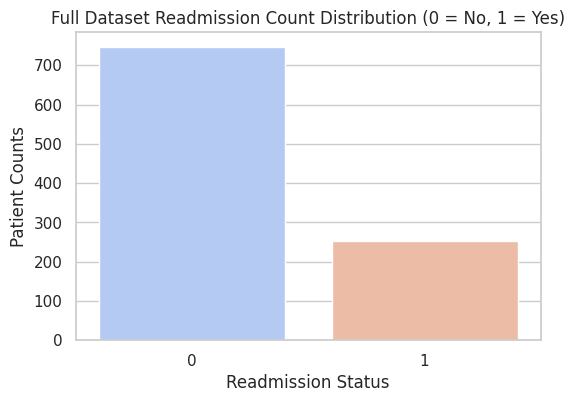

In [24]:
# Visual: Readmission Target Distribution - Full Dataset

# Plot
plt.figure(figsize=(6, 4))

sns.countplot(
    x=raw_df[TARGET],
    hue=raw_df[TARGET],
    palette='coolwarm',
    legend=False
)

plt.title("Full Dataset Readmission Count Distribution (0 = No, 1 = Yes)")
plt.xlabel("Readmission Status")
plt.ylabel("Patient Counts")

plt.show()

### Visual 2: Length of Stay (Days) by Readmission Status

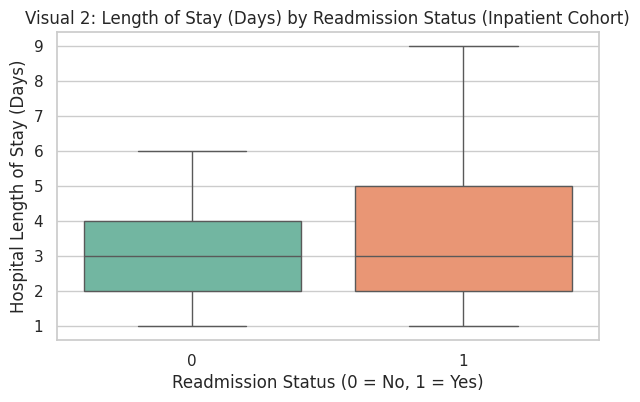

In [25]:
# Visual 2: Boxplot comparing length of stay grouped by readmission status
plt.figure(figsize=(7, 4))
sns.boxplot(x=df[TARGET], y=df['length_of_stay_days'], hue=df[TARGET], palette='Set2', legend=False)
plt.title("Visual 2: Length of Stay (Days) by Readmission Status (Inpatient Cohort)")
plt.xlabel("Readmission Status (0 = No, 1 = Yes)")
plt.ylabel("Hospital Length of Stay (Days)")
plt.show()


**EDA Insight 2:** Both classes have a median stay of about 3 days, but the readmitted group has a slightly higher mean stay (3.48 days) than the not-readmitted group (2.88 days). The overlap shows that length of stay alone cannot separate the classes well.

### Visual 3: Patient Age Distribution Stratified by Readmission

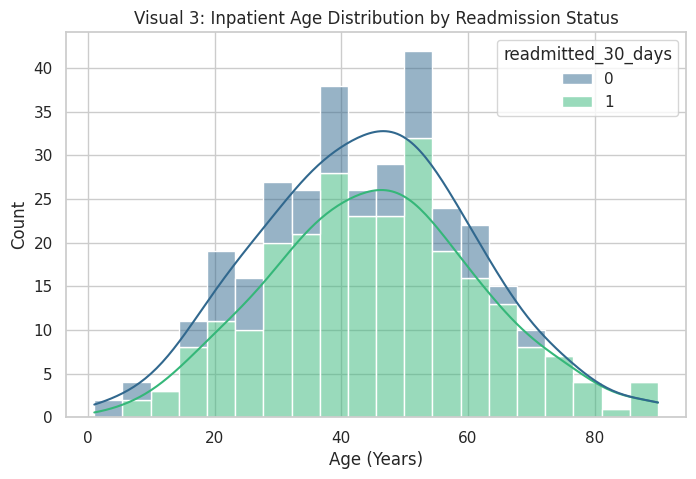

In [26]:
# Visual 3: Histogram showing age distributions stratified by target
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue=TARGET, multiple='stack', kde=True, palette='viridis', bins=20)
plt.title("Visual 3: Inpatient Age Distribution by Readmission Status")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()

**EDA Insight 3:** Readmitted patients are slightly older on average (45.79 years) than not-readmitted patients (39.22 years), but the distributions overlap considerably. Age therefore provides some signal but is not sufficient by itself.

### Visual 4: Relationship between Length of Stay and Total Bill Charges

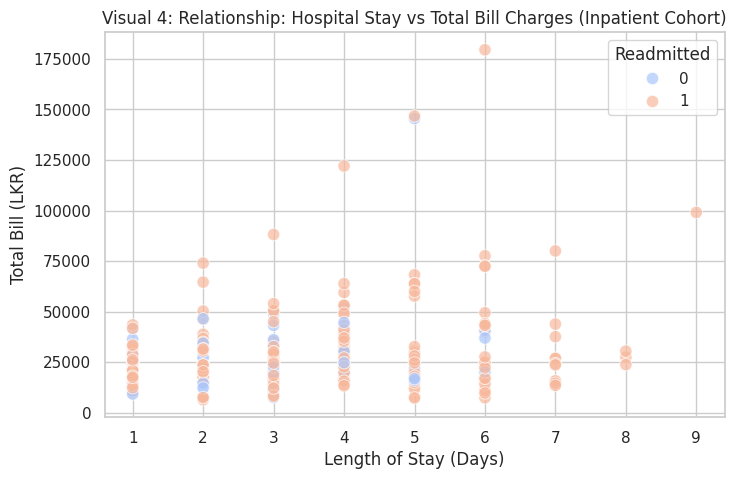

In [27]:
# Visual 4: Scatter Plot: Length of stay vs Total bill amount colored by readmission
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df['length_of_stay_days'],
    y=df['total_bill_lkr'],
    hue=df[TARGET],
    palette='coolwarm',
    alpha=0.7,
    s=80
)
plt.title("Visual 4: Relationship: Hospital Stay vs Total Bill Charges (Inpatient Cohort)")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Bill (LKR)")
plt.legend(title="Readmitted")
plt.show()

**EDA Insight 4:** Length of stay and total bill have a modest positive correlation (approximately 0.22). Longer stays often have higher bills, but the wide spread indicates that other clinical and service factors also affect billing and readmission.

### Visual 5: Correlation Matrix Heatmap of Numerical Features

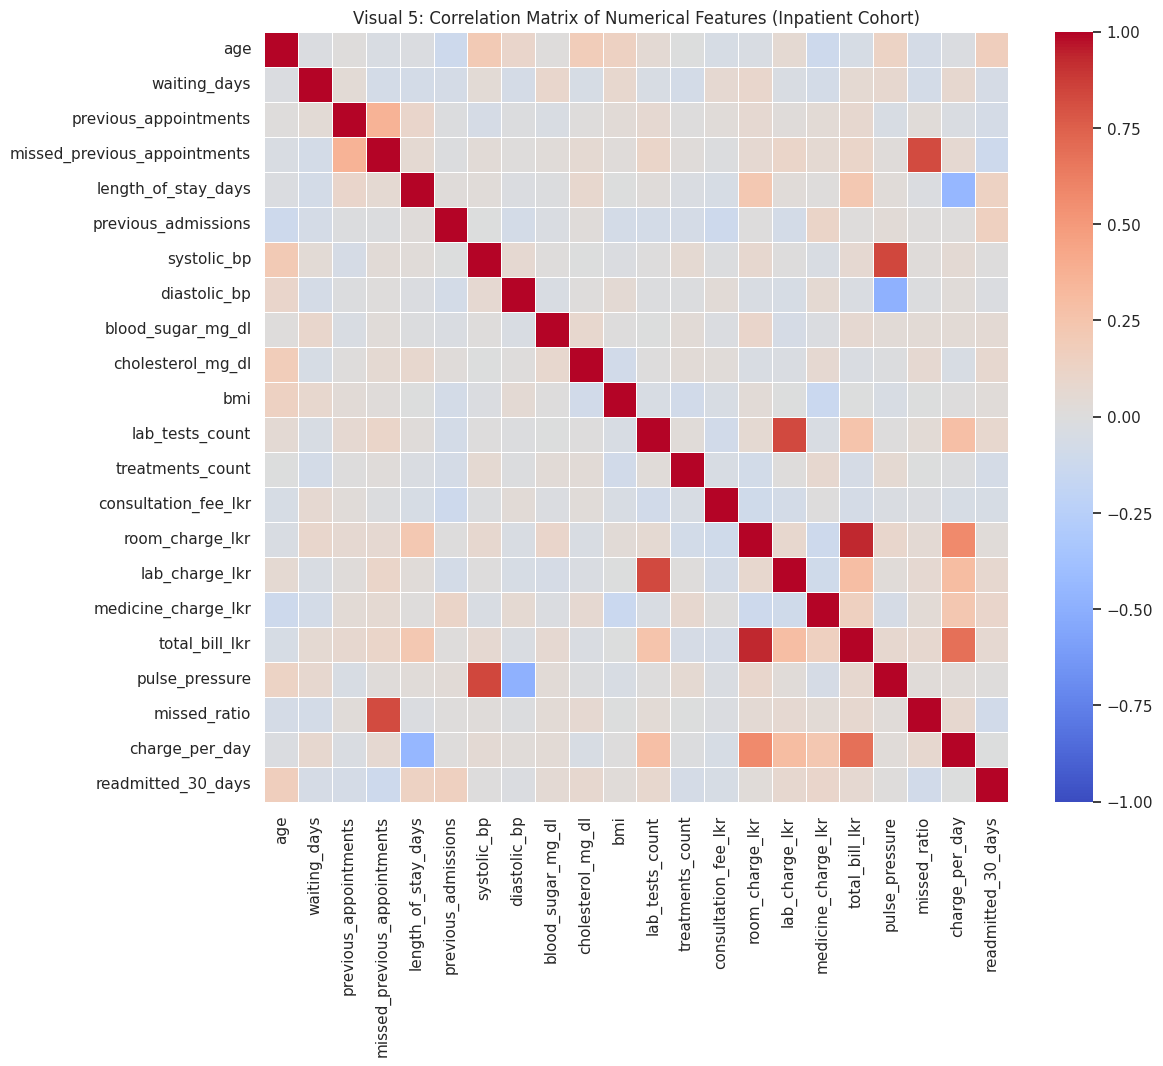

In [28]:
# Visual 5: Heatmap showing correlation coefficients among numerical features and target
plt.figure(figsize=(12, 10))
numeric_cols_with_target = num_cols + [TARGET]
corr_matrix = df[numeric_cols_with_target].corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Visual 5: Correlation Matrix of Numerical Features (Inpatient Cohort)")
plt.show()

**EDA Insight 5:** No single numerical variable has a strong linear correlation with readmission. The largest simple correlations with the target are still relatively small (for example, age about 0.17, previous admissions about 0.15, and length of stay about 0.14), supporting the use of multivariable machine learning models.

# Task 05 – Machine Learning Model Development & Stratified Cross-Validation

We train three machine learning classifiers (Decision Tree, K-Nearest Neighbors, and Random Forest). All three are evaluated using **Stratified 5-Fold Cross-Validation** across the inpatient cohort ($N=330$). The Random Forest is additionally tuned using **GridSearchCV inside each outer fold**, giving it a nested hyperparameter-tuning process.

### 1. Decision Tree Classifier


In [29]:
# Decision Tree Pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=80)),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])

print("Decision Tree Pipeline Established.")

Decision Tree Pipeline Established.


### 2. K-Nearest Neighbors (KNN) Classifier

In [30]:
# KNN Pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=80)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

print("KNN Pipeline Established.")

KNN Pipeline Established.


### 3. Random Forest Classifier (GridSearchCV with Inner Stratified CV)


In [31]:
# Random Forest Pipeline with GridSearch hyperparameter tuning
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=80)),
    ('classifier', rf_clf)
])

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [4, 6, 8, 10]
}

# Inner CV for hyperparameter selection
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=inner_cv,
    scoring='f1',
    n_jobs=1
)

print("GridSearchCV Random Forest Pipeline Established.")


GridSearchCV Random Forest Pipeline Established.


# Task 06 – Model Evaluation via Stratified Cross-Validation & Rigorous Model Selection

We evaluate Decision Tree and KNN using **Stratified 5-Fold Cross-Validation**. Random Forest uses the same outer 5-fold evaluation, with an inner 5-fold `GridSearchCV` for hyperparameter tuning. Metrics are computed from held-out folds, and cumulative out-of-fold confusion matrices and ROC curves are displayed.


In [32]:
# Outer CV for model evaluation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_dict = {
    "Decision Tree": dt_pipeline,
    "K-Nearest Neighbors": knn_pipeline,
    "Random Forest (Nested CV)": grid_search_rf
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

nested_cv_results = []
oof_confusion_matrices = {}

for name, model in models_dict.items():
    cv_res = cross_validate(model, X, y, cv=outer_cv, scoring=scoring_metrics, n_jobs=1)

    oof_preds = cross_val_predict(model, X, y, cv=outer_cv, n_jobs=1)
    oof_probs = cross_val_predict(model, X, y, cv=outer_cv, method='predict_proba', n_jobs=1)[:, 1]

    cm = confusion_matrix(y, oof_preds)
    tn, fp, fn, tp = cm.ravel()
    oof_confusion_matrices[name] = (cm, oof_preds, oof_probs)

    nested_cv_results.append({
        "Model": name,
        "CV Mean Accuracy": f"{cv_res['test_accuracy'].mean():.4f} +/- {cv_res['test_accuracy'].std():.4f}",
        "CV Mean Precision": f"{cv_res['test_precision'].mean():.4f} +/- {cv_res['test_precision'].std():.4f}",
        "CV Mean Recall": f"{cv_res['test_recall'].mean():.4f} +/- {cv_res['test_recall'].std():.4f}",
        "CV Mean F1-Score": f"{cv_res['test_f1'].mean():.4f} +/- {cv_res['test_f1'].std():.4f}",
        "CV Mean ROC-AUC": f"{cv_res['test_roc_auc'].mean():.4f} +/- {cv_res['test_roc_auc'].std():.4f}",
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    })

nested_summary_df = pd.DataFrame(nested_cv_results)
print("--- Stratified 5-Fold Cross-Validation Summary Table (N = 330) ---")
display(nested_summary_df[["Model", "CV Mean Accuracy", "CV Mean Precision", "CV Mean Recall", "CV Mean F1-Score", "CV Mean ROC-AUC"]])

print("\n--- Out-of-Fold Cumulative Confusion Matrix Counts ---")
display(nested_summary_df[["Model", "TN", "FP", "FN", "TP"]])


--- Stratified 5-Fold Cross-Validation Summary Table (N = 330) ---


,Model,CV Mean Accuracy,CV Mean Precision,CV Mean Recall,CV Mean F1-Score,CV Mean ROC-AUC
0,Decision Tree,0.7030 +/- 0.0466,0.7738 +/- 0.0291,0.8653 +/- 0.0468,0.8166 +/- 0.0324,0.5595 +/- 0.1006
1,K-Nearest Neighbors,0.7212 +/- 0.0246,0.7637 +/- 0.0107,0.9207 +/- 0.0287,0.8348 +/- 0.0175,0.5442 +/- 0.1121
2,Random Forest (Nested CV),0.7636 +/- 0.0074,0.7677 +/- 0.0091,0.9922 +/- 0.0096,0.8655 +/- 0.0043,0.5726 +/- 0.0540



--- Out-of-Fold Cumulative Confusion Matrix Counts ---


,Model,TN,FP,FN,TP
0,Decision Tree,13,64,34,219
1,K-Nearest Neighbors,5,72,20,233
2,Random Forest (Nested CV),1,76,2,251


### Simple Majority-Class Baseline

A `DummyClassifier` is included as a sanity-check baseline. It is **not one of the three coursework models**. Because 76.7% of the inpatient cohort belongs to the readmitted class, this baseline shows how much performance can be obtained simply by always predicting the majority class.

In [33]:
# Simple majority-class baseline for comparison only
dummy_model = DummyClassifier(strategy='most_frequent')

dummy_cv = cross_validate(
    dummy_model, X, y, cv=outer_cv, scoring=scoring_metrics, n_jobs=1
)
dummy_oof_preds = cross_val_predict(dummy_model, X, y, cv=outer_cv, n_jobs=1)
dummy_cm = confusion_matrix(y, dummy_oof_preds)
dummy_tn, dummy_fp, dummy_fn, dummy_tp = dummy_cm.ravel()

print("--- Dummy Majority-Class Baseline ---")
print(f"Accuracy:  {dummy_cv['test_accuracy'].mean():.4f} +/- {dummy_cv['test_accuracy'].std():.4f}")
print(f"Precision: {dummy_cv['test_precision'].mean():.4f} +/- {dummy_cv['test_precision'].std():.4f}")
print(f"Recall:    {dummy_cv['test_recall'].mean():.4f} +/- {dummy_cv['test_recall'].std():.4f}")
print(f"F1-Score:  {dummy_cv['test_f1'].mean():.4f} +/- {dummy_cv['test_f1'].std():.4f}")
print(f"ROC-AUC:   {dummy_cv['test_roc_auc'].mean():.4f} +/- {dummy_cv['test_roc_auc'].std():.4f}")
print(f"Confusion Matrix Counts: TN={dummy_tn}, FP={dummy_fp}, FN={dummy_fn}, TP={dummy_tp}")


--- Dummy Majority-Class Baseline ---
Accuracy:  0.7667 +/- 0.0074
Precision: 0.7667 +/- 0.0074
Recall:    1.0000 +/- 0.0000
F1-Score:  0.8679 +/- 0.0048
ROC-AUC:   0.5000 +/- 0.0000
Confusion Matrix Counts: TN=0, FP=77, FN=0, TP=253


### Model 1 Out-of-Fold Confusion Matrix: Decision Tree

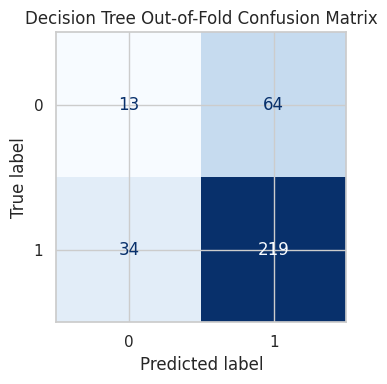

In [34]:
# Plot Decision Tree Confusion Matrix individually
fig, ax = plt.subplots(figsize=(5, 4))
dt_oof_preds = oof_confusion_matrices["Decision Tree"][1]
ConfusionMatrixDisplay.from_predictions(y, dt_oof_preds, ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Decision Tree Out-of-Fold Confusion Matrix")
plt.tight_layout()
plt.show()

### Model 2 Out-of-Fold Confusion Matrix: K-Nearest Neighbors (KNN)

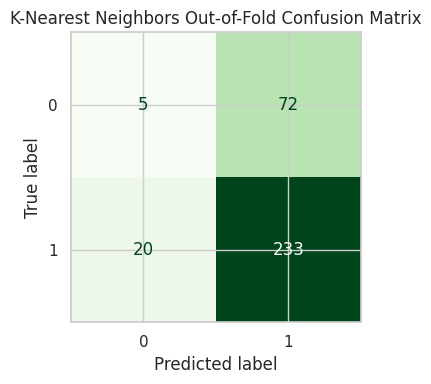

In [35]:
# Plot KNN Confusion Matrix individually
fig, ax = plt.subplots(figsize=(5, 4))
knn_oof_preds = oof_confusion_matrices["K-Nearest Neighbors"][1]
ConfusionMatrixDisplay.from_predictions(y, knn_oof_preds, ax=ax, cmap='Greens', colorbar=False)
ax.set_title("K-Nearest Neighbors Out-of-Fold Confusion Matrix")
plt.tight_layout()
plt.show()

### Model 3 Out-of-Fold Confusion Matrix: Random Forest (Optimized)

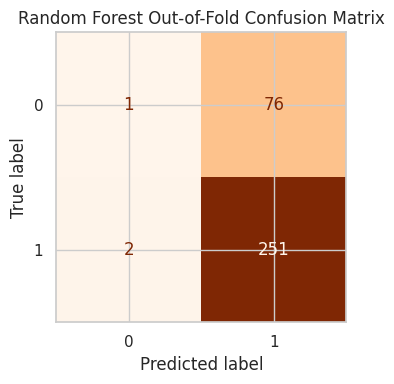

In [36]:
# Plot Random Forest Confusion Matrix individually
fig, ax = plt.subplots(figsize=(5, 4))
rf_oof_preds = oof_confusion_matrices["Random Forest (Nested CV)"][1]
ConfusionMatrixDisplay.from_predictions(y, rf_oof_preds, ax=ax, cmap='Oranges', colorbar=False)
ax.set_title("Random Forest Out-of-Fold Confusion Matrix")
plt.tight_layout()
plt.show()

### Comparative Receiver Operating Characteristic (ROC) Curves

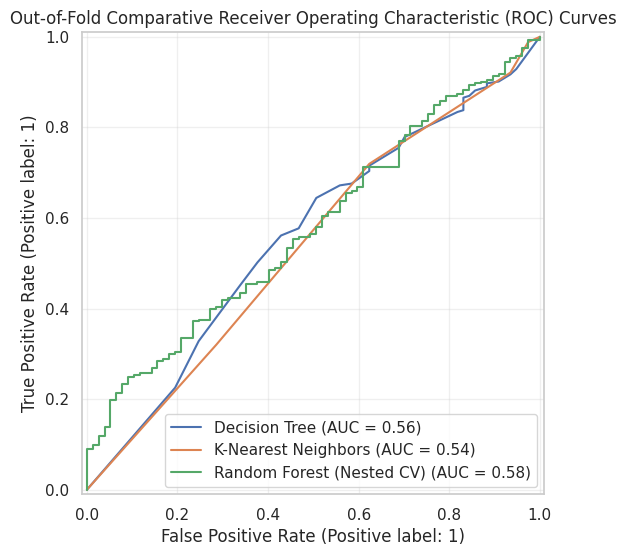

In [37]:
# Plot Out-of-Fold ROC Curves individually
plt.figure(figsize=(8, 6))
ax = plt.gca()

for name, (_, _, oof_probs) in oof_confusion_matrices.items():
    RocCurveDisplay.from_predictions(y, oof_probs, name=name, ax=ax)

plt.title("Out-of-Fold Comparative Receiver Operating Characteristic (ROC) Curves")
plt.grid(True, alpha=0.3)
plt.show()

### Rigorous Model Selection Rationale

1. **Best among the three coursework models:** Random Forest has the highest mean Accuracy (**0.7636 ± 0.0074**), Recall (**0.9922 ± 0.0096**), F1-Score (**0.8655 ± 0.0043**), and ROC-AUC (**0.5726 ± 0.0540**). Decision Tree has marginally higher Precision (**0.7738**) than Random Forest (**0.7677**).
2. **Clinical sensitivity:** Random Forest produces only **2 false negatives** and **251 true positives** in the out-of-fold predictions, so it misses very few readmitted patients.
3. **Stability:** Random Forest has the smallest F1 fold-to-fold standard deviation (**0.0043**) among the three candidate models.
4. **Important baseline warning:** The majority-class `DummyClassifier` obtains approximately **0.7667 Accuracy**, **1.0000 Recall**, **0.8679 F1**, and **0.5000 ROC-AUC** by predicting almost every patient as readmitted. Therefore, the Random Forest is selected as the best of the three trained coursework models, but its low ROC-AUC and very low true-negative count show that its practical discrimination is weak.
5. **Literature comparison:** The Random Forest ROC-AUC (**0.5726**) is well below the **0.75–0.76 AUROC** reported for large deep-EHR models, and is closer to the weak discrimination range reported for traditional administrative readmission models.


###Task 7 – Explainable AI, Fairness and Ethics

our main purpose was to understand why the machine learning model makes a prediction, instead of only showing the final result.

Calculating Baseline Permutation Feature Importance (Full Dataset N=1000)...


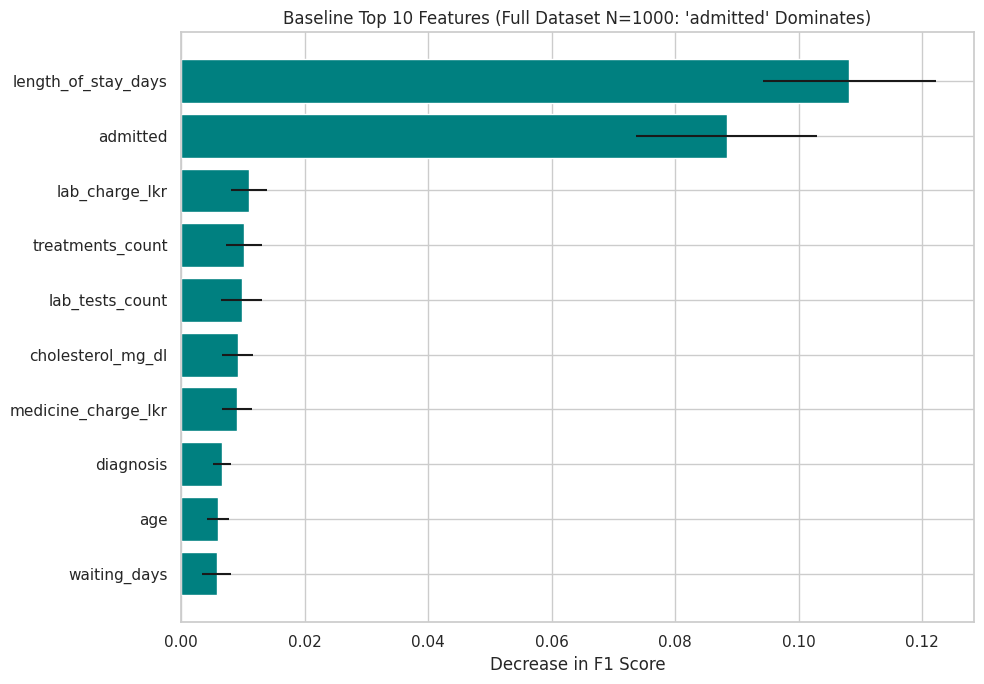

In [38]:
# Fit baseline Random Forest model on full dataset (N=1000)
drop_cols_raw = ['record_id', 'patient_id', 'appointment_date', 'no_show', 'disease_risk_level', TARGET]
X_raw = raw_df.drop(columns=drop_cols_raw)
y_raw = raw_df[TARGET]

num_cols_raw = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_raw = X_raw.select_dtypes(include=['object', 'string']).columns.tolist()

preprocessor_raw = ColumnTransformer([
    ('num', StandardScaler(), num_cols_raw),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols_raw)
])

rf_base_pipeline = Pipeline([
    ('preprocessor', preprocessor_raw),
    ('selector', SelectPercentile(score_func=f_classif, percentile=80)),
    ('classifier', RandomForestClassifier(max_depth=6, n_estimators=50, random_state=RANDOM_STATE))
])

rf_base_pipeline.fit(X_raw, y_raw)

# Calculate Baseline Permutation Feature Importance (N=1000)
print("Calculating Baseline Permutation Feature Importance (Full Dataset N=1000)...")
res_base = permutation_importance(
    rf_base_pipeline, X_raw, y_raw, n_repeats=30, random_state=RANDOM_STATE, scoring='f1', n_jobs=1
)

sorted_idx_base = res_base.importances_mean.argsort()[::-1]
feature_names_raw = X_raw.columns.tolist()

# Plot Baseline Permutation Feature Importance (N=1000)
plt.figure(figsize=(10, 7))
top_indices_base = sorted_idx_base[:10]
plt.barh(
    [feature_names_raw[i] for i in top_indices_base][::-1],
    res_base.importances_mean[top_indices_base][::-1],
    xerr=res_base.importances_std[top_indices_base][::-1],
    color='teal'
)
plt.title("Baseline Top 10 Features (Full Dataset N=1000: 'admitted' Dominates)")
plt.xlabel("Decrease in F1 Score")
plt.tight_layout()
plt.show()


### 2. Refined Global Permutation Feature Importance (Discharged Inpatient Cohort, N=330)

*After restricting the cohort to discharged inpatients ($N=330$), the refined permutation-importance plot is driven by variables such as `lab_tests_count`, `cholesterol_mg_dl`, `waiting_days`, `medicine_charge_lkr`, `lab_charge_lkr`, `diagnosis`, `blood_sugar_mg_dl`, `total_bill_lkr`, `treatments_count`, and related clinical/service variables. This removes the artificial dominance of the `admitted` flag.*


Final Inpatient Random Forest Model Fitted. Best Parameters: {'classifier__max_depth': 4, 'classifier__n_estimators': 150}
Calculating Refined Permutation Feature Importance (Inpatient Cohort N=330)...


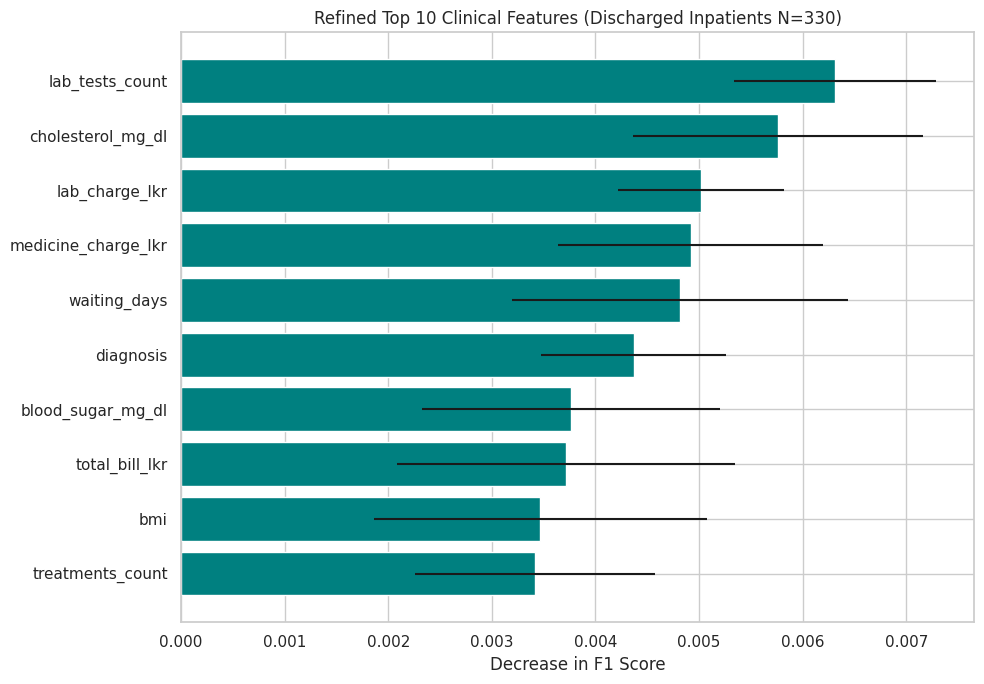

In [39]:
# Fit final tuned Random Forest model on full inpatient cohort for XAI and serialization
grid_search_rf.fit(X, y)
best_rf_pipeline = grid_search_rf.best_estimator_
print(f"Final Inpatient Random Forest Model Fitted. Best Parameters: {grid_search_rf.best_params_}")

# Calculate Refined Permutation Feature Importance on Inpatient Cohort (N=330)
print("Calculating Refined Permutation Feature Importance (Inpatient Cohort N=330)...")
feature_names = X.columns.tolist()

result = permutation_importance(
    best_rf_pipeline, X, y, n_repeats=30, random_state=RANDOM_STATE, scoring='f1', n_jobs=1
)

sorted_importances_idx = result.importances_mean.argsort()[::-1]

# Plot Refined Permutation Feature Importance (N=330)
plt.figure(figsize=(10, 7))
top_indices = sorted_importances_idx[:10]
plt.barh(
    [feature_names[i] for i in top_indices][::-1],
    result.importances_mean[top_indices][::-1],
    xerr=result.importances_std[top_indices][::-1],
    color='teal'
)
plt.title("Refined Top 10 Clinical Features (Discharged Inpatients N=330)")
plt.xlabel("Decrease in F1 Score")
plt.tight_layout()
plt.show()


### 3. SHAP Global Feature Impact Summary Plot (Lundberg & Lee, 2017)

SHAP values calculated successfully!


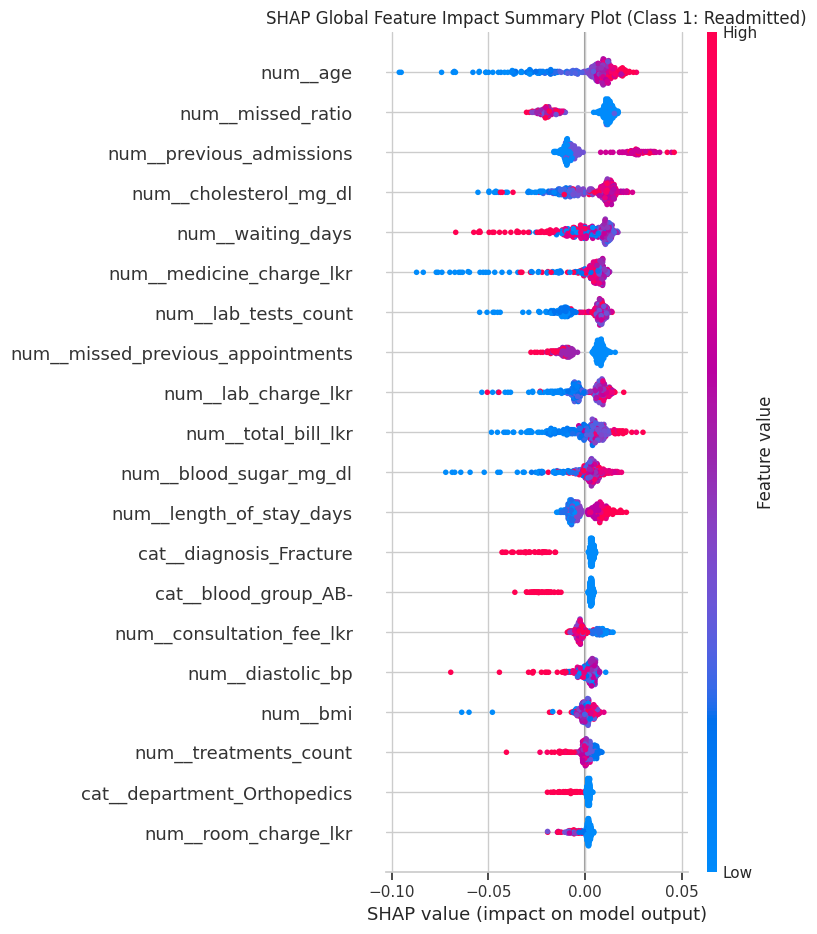

In [40]:
# Transform features through preprocessor and selector for SHAP analysis
X_trans = best_rf_pipeline.named_steps['preprocessor'].transform(X)
selector = best_rf_pipeline.named_steps['selector']
X_sel = selector.transform(X_trans)

# Get selected feature names
all_feature_names = best_rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_feature_names = [all_feature_names[i] for i, s in enumerate(selector.get_support()) if s]

# Compute TreeSHAP values
rf_clf_model = best_rf_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(rf_clf_model)
shap_values = explainer.shap_values(X_sel)

# Handle multi-output SHAP array format
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

print("SHAP values calculated successfully!")

# Plot SHAP Summary Plot individually
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, X_sel, feature_names=selected_feature_names, show=False)
plt.title("SHAP Global Feature Impact Summary Plot (Class 1: Readmitted)")
plt.tight_layout()
plt.show()

### 4. SHAP Local Feature Attribution for Individual Patient #1

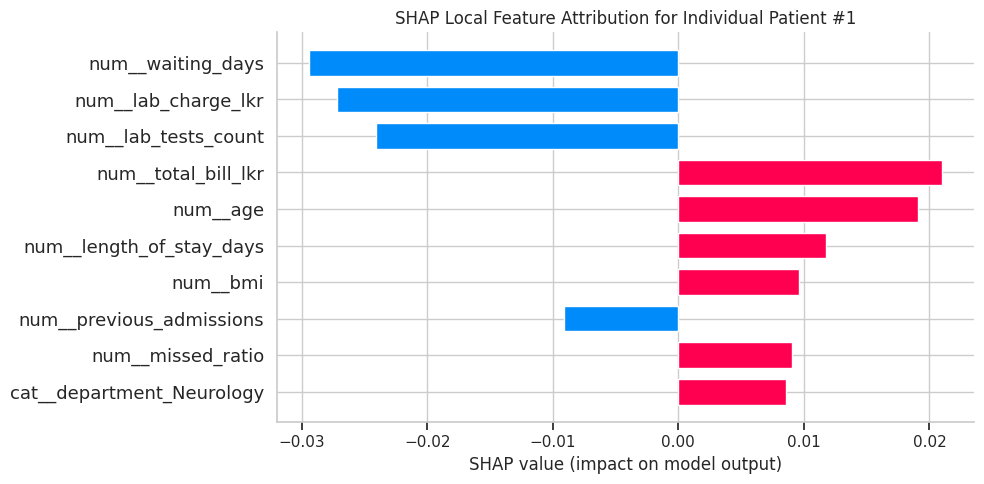

In [41]:
# Plot Local SHAP Explanation for Patient #1 individually
patient_idx = 0
plt.figure(figsize=(10, 5))
shap.bar_plot(
    shap_vals_class1[patient_idx],
    feature_names=selected_feature_names,
    max_display=10,
    show=False
)
plt.title(f"SHAP Local Feature Attribution for Individual Patient #{patient_idx+1}")
plt.tight_layout()
plt.show()

### 5. Subgroup Fairness Evaluation

Fairness cannot be assumed merely by excluding demographic variables ("fairness through unawareness"). We evaluate subgroup fairness by disaggregating performance metrics across demographic subgroups (`Gender` and `Age Group`).

In [42]:
eval_df = X.copy()
eval_df['y_true'] = y.values
eval_df['y_pred'] = rf_oof_preds

fairness_records = []

# Gender Subgroups
for gender in eval_df['gender'].unique():
    sub = eval_df[eval_df['gender'] == gender]
    acc = accuracy_score(sub['y_true'], sub['y_pred'])
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    prec = precision_score(sub['y_true'], sub['y_pred'], zero_division=0)
    f1 = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
    fairness_records.append({
        "Attribute": "Gender",
        "Subgroup": gender,
        "Sample Count (N)": len(sub),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Age Subgroups (<50 vs >=50)
eval_df['age_group'] = np.where(eval_df['age'] < 50, "Age < 50", "Age >= 50")
for age_grp in eval_df['age_group'].unique():
    sub = eval_df[eval_df['age_group'] == age_grp]
    acc = accuracy_score(sub['y_true'], sub['y_pred'])
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    prec = precision_score(sub['y_true'], sub['y_pred'], zero_division=0)
    f1 = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
    fairness_records.append({
        "Attribute": "Age Group",
        "Subgroup": age_grp,
        "Sample Count (N)": len(sub),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

fairness_df = pd.DataFrame(fairness_records)
print("--- Demographic Subgroup Fairness Performance Table ---")
display(fairness_df.round(4))


--- Demographic Subgroup Fairness Performance Table ---


,Attribute,Subgroup,Sample Count (N),Accuracy,Precision,Recall,F1-Score
0,Gender,Female,173,0.7746,0.7791,0.9926,0.8730
1,Gender,Male,157,0.7516,0.7548,0.9915,0.8571
2,Age Group,Age >= 50,129,0.8062,0.8110,0.9904,0.8918
3,Age Group,Age < 50,201,0.7363,0.7400,0.9933,0.8481


### Subgroup Fairness Discussion

- **Out-of-fold evaluation:** Subgroup metrics use the Random Forest out-of-fold predictions, so each patient is evaluated by a model that did not train on that patient's row.
- **Recall / sensitivity parity:** Recall is very high in all reported gender and age subgroups (approximately 0.99), so the model misses few readmitted patients in each subgroup.
- **Precision differences:** Small differences in precision are observed between subgroups. These differences may come from subgroup base rates and/or model behaviour, so they should not be treated as proof of either fairness or bias.
- **Important limitation:** High subgroup recall is partly caused by the model predicting the majority `readmitted` class very often. Fairness results must therefore be interpreted together with the low overall true-negative count and weak ROC-AUC.

### Ethical Considerations

- The SmartCare dataset is synthetic, so the model has **not** been clinically validated on real patients.
- False negatives could miss a patient who needs follow-up, while false positives could create unnecessary workload and anxiety.
- Demographic subgroup performance should be monitored because high overall performance does not automatically guarantee fairness.
- Real healthcare systems must protect patient privacy and use appropriate access controls for clinical data.
- The Streamlit application is an **educational decision-support prototype only**. It should support, not replace, qualified clinical judgement.

# Task 08 – AI Prototype Development (Streamlit Dashboard Setup)

We save the trained production pipeline and preprocessor for integration with the Streamlit app (`app.py`).


In [43]:
# Save trained pipeline and preprocessor
joblib.dump(best_rf_pipeline, "best_readmission_rf_model.joblib")
joblib.dump(best_rf_pipeline.named_steps['preprocessor'], "readmission_preprocessor.joblib")
print("Saved production RandomForest pipeline successfully!")
print("Saved preprocessor pipeline successfully!")

Saved production RandomForest pipeline successfully!
Saved preprocessor pipeline successfully!


## References

[1] A. Rajkomar et al., "Scalable and accurate deep learning with electronic health records," *npj Digital Medicine*, vol. 1, Art. no. 18, 2018, doi: 10.1038/s41746-018-0029-1.  
[Online]. Available: https://doi.org/10.1038/s41746-018-0029-1

[2] D. Kansagara, H. Englander, A. Salanitro, D. Kagen, C. Theobald, M. Freeman, and S. Kripalani, "Risk prediction models for hospital readmission: A systematic review," *JAMA*, vol. 306, no. 15, pp. 1688–1698, 2011, doi: 10.1001/jama.2011.1515.  
[Online]. Available: https://doi.org/10.1001/jama.2011.1515

[3] S. M. Lundberg and S.-I. Lee, "A unified approach to interpreting model predictions," in *Advances in Neural Information Processing Systems 30*, 2017, pp. 4765–4774.  
[Online]. Available: https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

[4] R. Caruana, Y. Lou, J. Gehrke, P. Koch, M. Sturm, and N. Elhadad, "Intelligible models for healthcare: Predicting pneumonia risk and hospital 30-day readmission," in *Proc. 21st ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, Sydney, Australia, 2015, pp. 1721–1730, doi: 10.1145/2783258.2788613.  
[Online]. Available: https://doi.org/10.1145/2783258.2788613

[5] R. Amarasingham, B. J. Moore, Y. P. Tabak, M. H. Drazner, C. A. Clark, S. Zhang, W. G. Reed, T. S. Swanson, Y. Ma, and E. A. Halm, "An automated model to identify heart failure patients at risk for 30-day readmission or death using electronic medical record data," *Medical Care*, vol. 48, no. 11, pp. 981–988, 2010, doi: 10.1097/MLR.0b013e3181ef60d9.  
[Online]. Available: https://doi.org/10.1097/MLR.0b013e3181ef60d9